# Hindi/Hinglish Sentiment Analysis — LSTM Architecture Comparison

**Unit IV – RNN/LSTM: text sentiment classification (Mini Project version)**

This notebook runs the full experiment end to end. It uses the same code as `train.py`:

1. Load the code-mixed review dataset (Roman Urdu / Roman Hindi / English e-commerce reviews, 3 classes)
2. Clean the text, then **remove duplicates after cleaning** so no review can be in both the training and test sets
3. Fixed stratified 70 / 15 / 15 split, tokenizer fitted on training data only
4. Train **3 architectures × 3 random seeds**: Simple LSTM, Stacked BiLSTM, CNN + BiLSTM
5. Evaluate on the test set with Accuracy, Macro-F1, Weighted-F1, RMSE and report **mean ± std**
6. Plot training/validation **loss and accuracy** curves, comparison chart and confusion matrix

**Dataset:** Ghaffar, Z. & Noor, M. N. (2025). *Dataset for Sentiment Analysis in Code-Mixed Language* (Version 1). Mendeley Data. https://doi.org/10.17632/xxprggbztd.1

In [1]:
# Run from the project root so the data/, models/ and results/ paths resolve
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("Working directory:", os.getcwd())

Working directory: /home/claude/proj


## Imports and configuration

In [2]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_squared_error,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
%matplotlib inline

from preprocessing import clean_text

from models.simple_lstm import build_simple_lstm
from models.stacked_bilstm import build_stacked_bilstm
from models.cnn_bilstm import build_cnn_bilstm

DATA_FILE = "./data/hinglish_reviews.csv"

TEXT_COL = "Review"
LABEL_COL = "Sentiment"

MAX_VOCAB_SIZE = 20000
MAX_SEQ_LEN = 60
EMBEDDING_DIM = 128

BATCH_SIZE = 32
EPOCHS = 25

# The data split is fixed with SPLIT_SEED so every run is tested on
# the same reviews. Each architecture is trained once per seed in
# TRAINING_SEEDS (weight initialisation, dropout, batch shuffling).
SPLIT_SEED = 42
TRAINING_SEEDS = [42, 123, 2024]

TEST_SIZE = 0.15
VAL_SIZE = 0.15

OUTPUT_DIR = "./results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

warnings.filterwarnings("ignore")

I0000 00:00:1791141737.741238     228 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791141750.832051     228 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1791141758.238568     228 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Load Data

In [3]:
print("=" * 70)
print("LOADING DATASET")
print("=" * 70)

df = pd.read_csv(DATA_FILE)

df = df.rename(
    columns={TEXT_COL: "text", LABEL_COL: "label"}
)[["text", "label"]]

df = df.dropna(subset=["text", "label"])

print(f"Original rows: {len(df)}")

LOADING DATASET
Original rows: 5034


## 2. Text Cleaning + Deduplication (After Cleaning)

In [4]:
df["clean_text"] = df["text"].apply(clean_text)

df = df[df["clean_text"].str.len() > 0]

# Reviews that become identical after cleaning but carry different
# labels are ambiguous, so they are dropped entirely.
labels_per_text = df.groupby("clean_text")["label"].nunique()
conflicting = labels_per_text[labels_per_text > 1].index

df = df[~df["clean_text"].isin(conflicting)]

# Remove duplicates on the CLEANED text, so the same review cannot
# appear in both the training and the test set.
df = df.drop_duplicates(subset=["clean_text"]).reset_index(drop=True)

print(f"Conflicting-label texts removed: {len(conflicting)}")
print(f"Rows after cleaning + deduplication: {len(df)}")

print("\nClass distribution:")
print(df["label"].value_counts())

Conflicting-label texts removed: 1
Rows after cleaning + deduplication: 4780

Class distribution:
label
positive    2225
negative    1597
neutral      958
Name: count, dtype: int64


## 3. Label Encoding

In [5]:
label_encoder = LabelEncoder()

df["label_id"] = label_encoder.fit_transform(df["label"])

num_classes = len(label_encoder.classes_)

print("\nClasses:")
print(list(label_encoder.classes_))


Classes:
['negative', 'neutral', 'positive']


## 4. Train / Validation / Test Split (Fixed)

In [6]:
X_temp, X_test, y_temp, y_test = train_test_split(
    df["clean_text"].values,
    df["label_id"].values,
    test_size=TEST_SIZE,
    stratify=df["label_id"].values,
    random_state=SPLIT_SEED
)

val_relative = VAL_SIZE / (1 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=val_relative,
    stratify=y_temp,
    random_state=SPLIT_SEED
)

# Sanity check: no review is shared between the splits
assert not set(X_train) & set(X_test)
assert not set(X_train) & set(X_val)
assert not set(X_val) & set(X_test)

print("\nDataset split:")
print(f"Train: {len(X_train)}")
print(f"Validation: {len(X_val)}")
print(f"Test: {len(X_test)}")


Dataset split:
Train: 3346
Validation: 717
Test: 717


## 5. Tokenization

In [7]:
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")

# Fit tokenizer ONLY on training data
tokenizer.fit_on_texts(X_train)

vocab_size = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)

print(f"\nVocabulary size: {vocab_size}")


# Pre-padding: zeros go BEFORE the review, so the LSTM reads the real
# words last and its final hidden state is not diluted by ~40 padding
# steps (the median review is 18 tokens). Post-padding made the
# one-directional Simple LSTM fail to train on 2 of 3 seeds.
# Reviews longer than MAX_SEQ_LEN (~3%) keep their first 60 tokens.
def to_padded(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    return pad_sequences(
        sequences,
        maxlen=MAX_SEQ_LEN,
        padding="pre",
        truncating="post"
    )


X_train_pad = to_padded(X_train)
X_val_pad = to_padded(X_val)
X_test_pad = to_padded(X_test)


Vocabulary size: 4369


## 6. Class Weights

In [8]:
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(zip(np.unique(y_train), class_weight_values))

print("\nClass weights:")
print(class_weights)


Class weights:
{np.int64(0): np.float64(0.9976147883124628), np.int64(1): np.float64(1.6621957277694983), np.int64(2): np.float64(0.7163348319417684)}


## 7. Model Architectures

In [9]:
architectures = {
    "Simple LSTM": build_simple_lstm,
    "Stacked BiLSTM": build_stacked_bilstm,
    "CNN + BiLSTM": build_cnn_bilstm
}

## 8. Train + Evaluate (Each Architecture × Each Seed)

In [10]:
run_results = []
runs = {}   # (architecture, seed) -> dict(model, history, y_pred)

for architecture_name, builder in architectures.items():

    for seed in TRAINING_SEEDS:

        print("\n")
        print("=" * 70)
        print(f"TRAINING: {architecture_name} | seed {seed}")
        print("=" * 70)

        # Seeds Python, NumPy and TensorFlow in one call
        tf.keras.utils.set_random_seed(seed)

        model = builder(
            vocab_size=vocab_size,
            max_seq_len=MAX_SEQ_LEN,
            embedding_dim=EMBEDDING_DIM,
            num_classes=num_classes
        )

        if seed == TRAINING_SEEDS[0]:
            model.summary()

        early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True
        )

        history = model.fit(
            X_train_pad,
            y_train,
            validation_data=(X_val_pad, y_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            class_weight=class_weights,
            callbacks=[early_stopping],
            verbose=2
        )

        y_pred = np.argmax(model.predict(X_test_pad, verbose=0), axis=1)

        accuracy = accuracy_score(y_test, y_pred)
        macro_f1 = f1_score(y_test, y_pred, average="macro")
        weighted_f1 = f1_score(y_test, y_pred, average="weighted")

        # RMSE on label-index space (negative=0, neutral=1, positive=2).
        # This is only an ordinal proxy.
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        print(
            f"\nAccuracy: {accuracy:.4f} | Macro-F1: {macro_f1:.4f} | "
            f"Weighted-F1: {weighted_f1:.4f} | RMSE: {rmse:.4f}"
        )

        run_results.append({
            "Architecture": architecture_name,
            "Seed": seed,
            "Accuracy": accuracy,
            "Macro_F1": macro_f1,
            "Weighted_F1": weighted_f1,
            "RMSE": rmse,
            "Params": model.count_params(),
            "Epochs_Run": len(history.history["loss"])
        })

        runs[(architecture_name, seed)] = {
            "model": model,
            "history": history.history,
            "y_pred": y_pred
        }



TRAINING: Simple LSTM | seed 42


Model: "A_Simple_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 60, 128)        │       559,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 60, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 610,819 (2.33 MB)

 Trainable params: 610,819 (2.33 MB)

...

Epoch 9/25


105/105 - 4s - 40ms/step - accuracy: 0.9955 - loss: 0.0157 - val_accuracy: 0.9596 - val_loss: 0.1700


Epoch 10/25


105/105 - 4s - 43ms/step - accuracy: 0.9979 - loss: 0.0085 - val_accuracy: 0.9554 - val_loss: 0.2037



Accuracy: 0.9693 | Macro-F1: 0.9611 | Weighted-F1: 0.9692 | RMSE: 0.1976


## 9. Comparison Tables (Per Run + Mean ± Std)

In [11]:
runs_df = pd.DataFrame(run_results)

runs_df.round(4).to_csv(
    os.path.join(OUTPUT_DIR, "architecture_runs.csv"),
    index=False
)

metric_cols = ["Accuracy", "Macro_F1", "Weighted_F1", "RMSE"]

summary = runs_df.groupby("Architecture", sort=False).agg(
    **{f"{m}_mean": (m, "mean") for m in metric_cols},
    **{f"{m}_std": (m, "std") for m in metric_cols},
    Params=("Params", "first"),
    Epochs_Mean=("Epochs_Run", "mean")
).reset_index()

summary = summary[
    ["Architecture"]
    + [c for m in metric_cols for c in (f"{m}_mean", f"{m}_std")]
    + ["Params", "Epochs_Mean"]
].sort_values("Macro_F1_mean", ascending=False)

summary.round(4).to_csv(
    os.path.join(OUTPUT_DIR, "architecture_comparison.csv"),
    index=False
)

print("\n")
print("=" * 70)
print(f"FINAL ARCHITECTURE COMPARISON (mean ± std over {len(TRAINING_SEEDS)} seeds)")
print("=" * 70)

pretty = summary[["Architecture"]].copy()
for m in metric_cols:
    pretty[m] = (
        summary[f"{m}_mean"].map("{:.4f}".format)
        + " ± "
        + summary[f"{m}_std"].map("{:.4f}".format)
    )
pretty["Params"] = summary["Params"]
print(pretty.to_string(index=False))



FINAL ARCHITECTURE COMPARISON (mean ± std over 3 seeds)
  Architecture        Accuracy        Macro_F1     Weighted_F1            RMSE  Params
   Simple LSTM 0.9661 ± 0.0029 0.9595 ± 0.0032 0.9662 ± 0.0028 0.2341 ± 0.0095  610819
  CNN + BiLSTM 0.9647 ± 0.0043 0.9570 ± 0.0038 0.9647 ± 0.0042 0.2297 ± 0.0319  670531
Stacked BiLSTM 0.9535 ± 0.0103 0.9451 ± 0.0106 0.9538 ± 0.0102 0.2691 ± 0.0540  701443


## 10. Model Comparison Chart (With Std Error Bars)

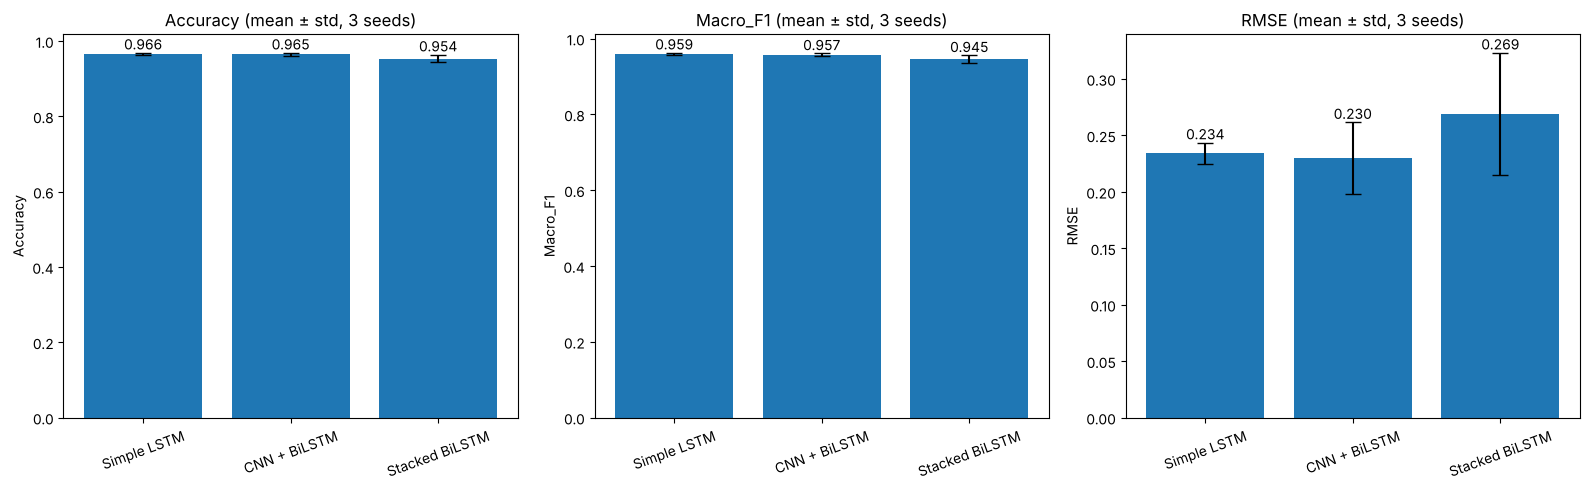

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ["Accuracy", "Macro_F1", "RMSE"]):

    means = summary[f"{metric}_mean"].values
    stds = summary[f"{metric}_std"].values

    ax.bar(summary["Architecture"], means, yerr=stds, capsize=6)
    ax.set_title(f"{metric} (mean ± std, {len(TRAINING_SEEDS)} seeds)")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=20)

    for i, (mean, std) in enumerate(zip(means, stds)):
        ax.text(i, mean + std, f"{mean:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "architecture_comparison.png"), dpi=150)
plt.show()

## 11. Best Model + Confusion Matrix


Classification report - Simple LSTM (seed 2024):
              precision    recall  f1-score   support

    negative       0.94      0.98      0.96       239
     neutral       0.95      0.93      0.94       144
    positive       1.00      0.98      0.99       334

    accuracy                           0.97       717
   macro avg       0.96      0.96      0.96       717
weighted avg       0.97      0.97      0.97       717



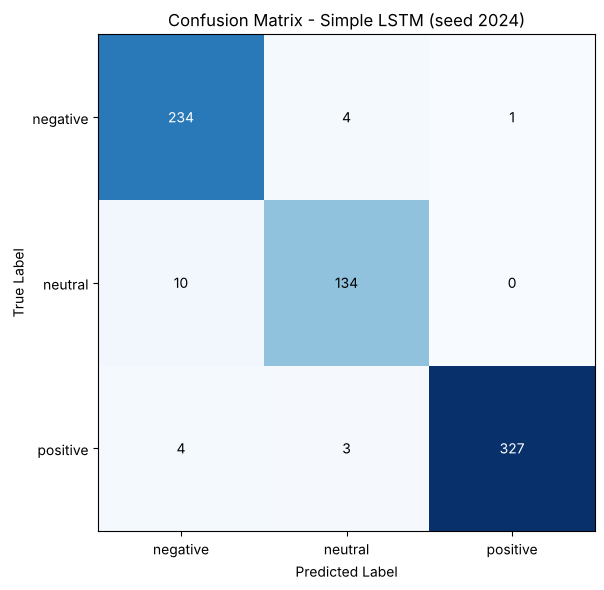

In [13]:
# Best architecture = highest MEAN Macro-F1; within it, the seed with
# the highest Macro-F1 is kept as the deployable model.
best_architecture = summary.iloc[0]["Architecture"]

best_seed = int(
    runs_df[runs_df["Architecture"] == best_architecture]
    .sort_values("Macro_F1", ascending=False)
    .iloc[0]["Seed"]
)

best_run = runs[(best_architecture, best_seed)]

print("\nClassification report - "
      f"{best_architecture} (seed {best_seed}):")
print(classification_report(
    y_test,
    best_run["y_pred"],
    target_names=label_encoder.classes_
))

cm = confusion_matrix(y_test, best_run["y_pred"])

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(cm, cmap="Blues")
ax.set_title(f"Confusion Matrix - {best_architecture} (seed {best_seed})")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(label_encoder.classes_)
ax.set_yticklabels(label_encoder.classes_)

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black"
        )

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

## 12. Training History (Train vs Validation Loss + Accuracy)

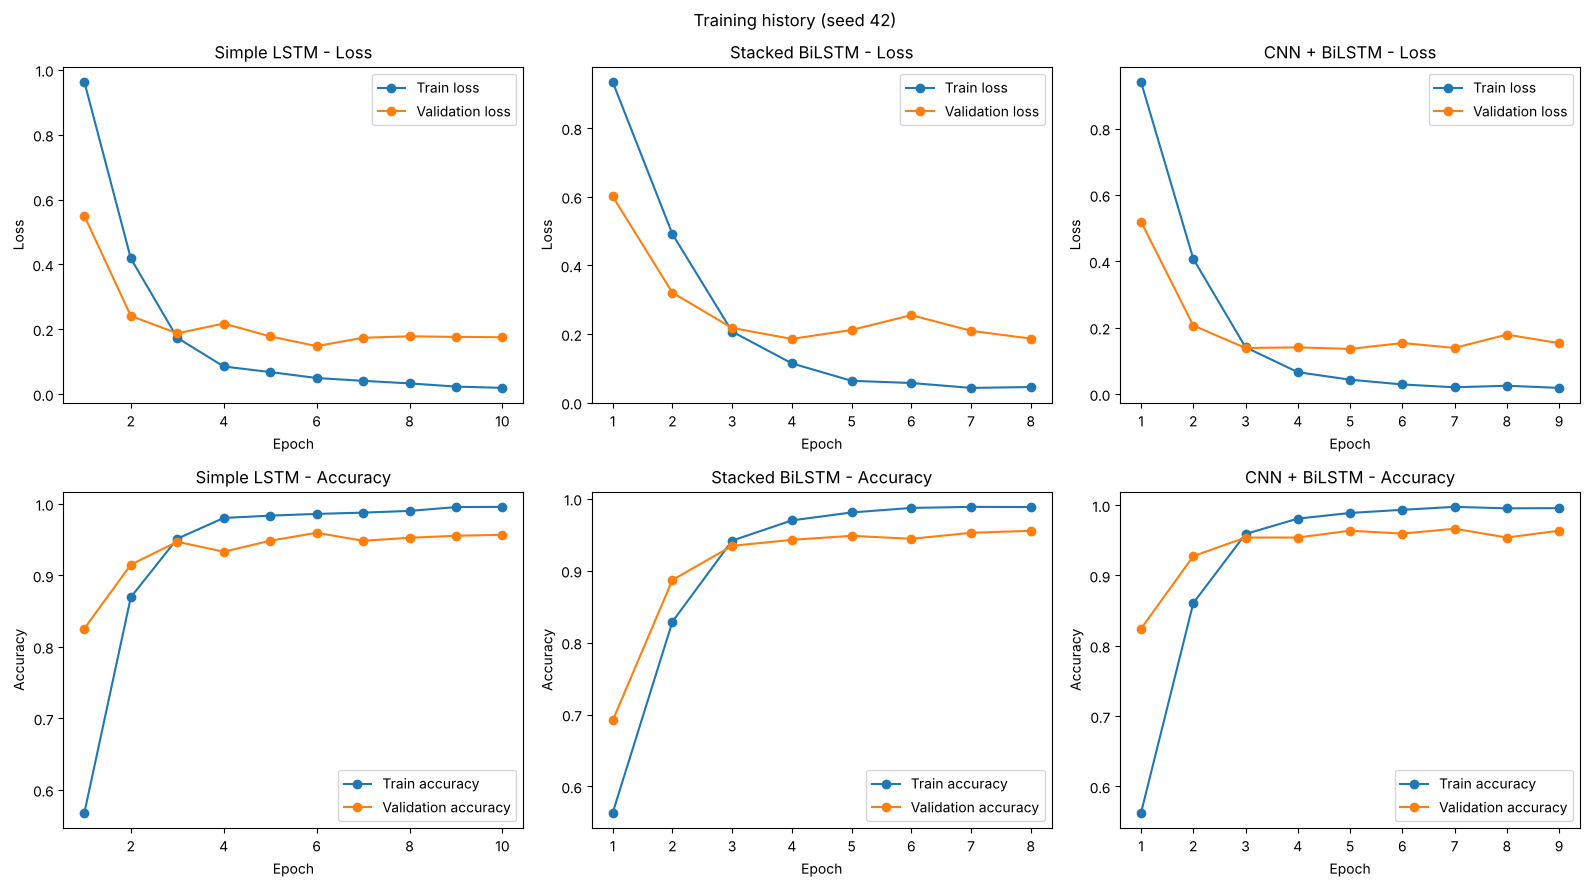

In [14]:
# Plotted for the first seed of each architecture. A widening gap
# between training and validation loss indicates overfitting.
history_seed = TRAINING_SEEDS[0]

fig, axes = plt.subplots(2, len(architectures), figsize=(16, 9))

for col, architecture_name in enumerate(architectures):

    h = runs[(architecture_name, history_seed)]["history"]
    epochs = range(1, len(h["loss"]) + 1)

    ax = axes[0, col]
    ax.plot(epochs, h["loss"], marker="o", label="Train loss")
    ax.plot(epochs, h["val_loss"], marker="o", label="Validation loss")
    ax.set_title(f"{architecture_name} - Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

    ax = axes[1, col]
    ax.plot(epochs, h["accuracy"], marker="o", label="Train accuracy")
    ax.plot(epochs, h["val_accuracy"], marker="o", label="Validation accuracy")
    ax.set_title(f"{architecture_name} - Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()

fig.suptitle(f"Training history (seed {history_seed})")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_history.png"), dpi=150)
plt.show()

## 13. Save Best Model, Tokenizer, Labels

In [15]:
best_run["model"].save(os.path.join(OUTPUT_DIR, "best_model.keras"))

with open(os.path.join(OUTPUT_DIR, "tokenizer.json"), "w", encoding="utf-8") as file:
    file.write(tokenizer.to_json())

with open(os.path.join(OUTPUT_DIR, "label_classes.json"), "w", encoding="utf-8") as file:
    json.dump(list(label_encoder.classes_), file, ensure_ascii=False, indent=4)


print("\n")
print("=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)
print(f"Best architecture: {best_architecture} (seed {best_seed})")
print("Saved model: results/best_model.keras")



TRAINING COMPLETE
Best architecture: Simple LSTM (seed 2024)
Saved model: results/best_model.keras


## 14. Testing On New, Hand-Written Reviews

The test set above measures accuracy on reviews from the same dataset. Here the models are tried on **new reviews written for this test**, grouped into categories that are known to be hard for sentiment models: negation, mixed opinions, sarcasm, spelling variants, very short inputs, and Hindi written in Devanagari script (which does not occur in the training data).

The *expected* label is what a human reader would assign. Each architecture is represented by its best seed. These cases were written before looking at the predictions and were not changed afterwards.

In [16]:
test_cases = [
    # (category, review, expected label)
    ("Clear positive",    "product bahut accha hai, quality bhi badhiya hai", "positive"),
    ("Clear positive",    "bohat zabardast cheez hai, seller ne time pe deliver kiya", "positive"),
    ("Clear negative",    "bilkul bekaar product hai, paisa barbaad ho gaya", "negative"),
    ("Clear negative",    "ghatiya quality hai, kabhi mat lena", "negative"),
    ("Clear neutral",     "theek hai, price ke hisaab se average hai", "neutral"),
    ("Clear neutral",     "product ok hai, na zyada acha na zyada bura", "neutral"),
    ("English only",      "excellent product, very good quality, highly recommended", "positive"),
    ("English only",      "worst product ever, totally waste of money", "negative"),
    ("English only",      "it is okay, works as described, nothing special", "neutral"),
    ("Negation",          "bilkul bhi acha nahi hai", "negative"),
    ("Negation",          "koi problem nahi hai, sab sahi chal raha hai", "positive"),
    ("Mixed opinion",     "quality achi hai lekin delivery bahut late thi", "neutral"),
    ("Sarcasm",           "wah kya baat hai, do din mein hi toot gaya", "negative"),
    ("Spelling variant",  "bht acha h yr, mza agya", "positive"),
    ("Spelling variant",  "bkwas h bhai, pesy zaya", "negative"),
    ("Very short",        "acha", "positive"),
    ("Very short",        "bekar", "negative"),
    ("Caps / emoji",      "SUPERB!!! 😍😍 must buy", "positive"),
    ("Domain: size",      "size chart galat hai, chhota aa gaya, return karna padega", "negative"),
    ("Devanagari Hindi",  "यह प्रोडक्ट बहुत अच्छा है", "positive"),
    ("Devanagari Hindi",  "बहुत खराब क्वालिटी है, पैसे बर्बाद", "negative"),
]

# Best seed of each architecture
best_seed_per_arch = (
    runs_df.sort_values("Macro_F1", ascending=False)
    .groupby("Architecture", sort=False).first()["Seed"].to_dict()
)

texts = [clean_text(r) for _, r, _ in test_cases]
X_cases = to_padded(texts)

case_df = pd.DataFrame(test_cases, columns=["Category", "Review", "Expected"])
case_df["Known words"] = [
    f"{sum(1 for w in t.split() if tokenizer.word_index.get(w, MAX_VOCAB_SIZE) < MAX_VOCAB_SIZE)}/{len(t.split())}"
    for t in texts
]

for arch in architectures:
    probs = runs[(arch, int(best_seed_per_arch[arch]))]["model"].predict(X_cases, verbose=0)
    preds = label_encoder.classes_[probs.argmax(axis=1)]
    case_df[arch] = [
        f"{'✓' if pr == exp else '✗'} {pr} ({pb.max():.0%})"
        for pr, pb, exp in zip(preds, probs, case_df["Expected"])
    ]
    case_df[f"_{arch}_ok"] = preds == case_df["Expected"].values

pd.set_option("display.max_colwidth", 70)
display(case_df[["Category", "Review", "Expected", "Known words"] + list(architectures)])

,Category,Review,Expected,Known words,Simple LSTM,Stacked BiLSTM,CNN + BiLSTM
0,Clear positive,"product bahut accha hai, quality bhi badhiya hai",positive,7/8,✓ positive (90%),✓ positive (94%),✓ positive (97%)
1,Clear positive,"bohat zabardast cheez hai, seller ne time pe deliver kiya",positive,10/10,✓ positive (91%),✓ positive (99%),✓ positive (100%)
2,Clear negative,"bilkul bekaar product hai, paisa barbaad ho gaya",negative,8/8,✓ negative (100%),✓ negative (100%),✓ negative (100%)
3,Clear negative,"ghatiya quality hai, kabhi mat lena",negative,6/6,✓ negative (95%),✓ negative (87%),✓ negative (100%)
4,Clear neutral,"theek hai, price ke hisaab se average hai",neutral,8/8,✓ neutral (99%),✓ neutral (98%),✓ neutral (100%)
5,Clear neutral,"product ok hai, na zyada acha na zyada bura",neutral,9/9,✓ neutral (60%),✓ neutral (87%),✗ negative (100%)
6,English only,"excellent product, very good quality, highly recommended",positive,7/7,✓ positive (100%),✓ positive (100%),✓ positive (100%)
7,English only,"worst product ever, totally waste of money",negative,7/7,✓ negative (100%),✓ negative (100%),✓ negative (100%)
8,English only,"it is okay, works as described, nothing special",neutral,8/8,✗ positive (75%),✓ neutral (88%),✓ neutral (78%)
9,Negation,bilkul bhi acha nahi hai,negative,5/5,✓ negative (95%),✓ negative (80%),✓ negative (100%)


### Score on the hand-written cases

In [17]:
ok_cols = {arch: f"_{arch}_ok" for arch in architectures}

overall = pd.DataFrame({
    arch: [f"{case_df[col].sum()} / {len(case_df)}"] for arch, col in ok_cols.items()
}, index=["Correct"])
display(overall)

by_category = case_df.groupby("Category", sort=False)[list(ok_cols.values())].agg(
    lambda s: f"{s.sum()}/{len(s)}"
)
by_category.columns = list(ok_cols)
display(by_category)

best_col = ok_cols[best_architecture]
print(f"Cases the best model ({best_architecture}) got wrong:")
for _, row in case_df[~case_df[best_col]].iterrows():
    print(f"  [{row['Category']}] {row['Review']!r} -> expected {row['Expected']}, got {row[best_architecture]}")

,Simple LSTM,Stacked BiLSTM,CNN + BiLSTM
Correct,18 / 21,18 / 21,16 / 21


,Simple LSTM,Stacked BiLSTM,CNN + BiLSTM
Category,,,
Clear positive,2/2,2/2,2/2
Clear negative,2/2,2/2,2/2
Clear neutral,2/2,2/2,1/2
English only,2/3,3/3,3/3
Negation,1/2,1/2,1/2
Mixed opinion,1/1,1/1,1/1
Sarcasm,1/1,1/1,1/1
Spelling variant,2/2,2/2,2/2
Very short,2/2,2/2,1/2


Cases the best model (Simple LSTM) got wrong:
  [English only] 'it is okay, works as described, nothing special' -> expected neutral, got ✗ positive (75%)
  [Negation] 'koi problem nahi hai, sab sahi chal raha hai' -> expected positive, got ✗ negative (90%)
  [Devanagari Hindi] 'यह प्रोडक्ट बहुत अच्छा है' -> expected positive, got ✗ negative (62%)


## Conclusion

Results on the 717-review test set, mean ± std over 3 training seeds (pre-padding):

| Model | Accuracy | Macro F1 | RMSE | Hand-written cases |
|---|---:|---:|---:|---:|
| **Simple LSTM** | **0.966 ± 0.003** | **0.960 ± 0.003** | 0.234 ± 0.010 | 18 / 21 |
| Stacked BiLSTM | 0.954 ± 0.010 | 0.945 ± 0.011 | 0.269 ± 0.054 | 18 / 21 |
| CNN + BiLSTM | 0.965 ± 0.004 | 0.957 ± 0.004 | **0.230 ± 0.032** | 16 / 21 |

- All three architectures reach about 95–97% accuracy. **Simple LSTM** has the highest mean macro F1 and the smallest spread, with the fewest parameters; CNN + BiLSTM is within one standard deviation of it. Its best run (seed 2024) is saved as `results/best_model.keras`.
- Reviews are short (median 18 tokens) and sentiment is carried mostly by strong words, so extra layers and bidirectional reading add parameters without a clear gain.
- **Padding mattered more than architecture:** with post-padding, the Simple LSTM failed on 2 of 3 seeds (70% ± 24 accuracy). Pre-padding lets the LSTM read the real words last and fixed this.
- The training curves show overfitting after about 3 epochs (training loss → 0, validation loss flat); early stopping restores the best-validation weights.
- On the hand-written cases, the models handle Roman Hindi, Roman Urdu, English, spelling variants, emoji and mixed opinions well. All three fail on the double negation *"koi problem nahi hai"*, and Devanagari input is not supported because the training data contains no Devanagari text.

*RMSE is computed on the label indices (negative = 0, neutral = 1, positive = 2) and is only a rough ordinal proxy for a classification task.*